In [2]:
import numpy as np
import joblib
import pandas as pd
from skimage import measure
from skimage.measure import shannon_entropy
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold


IMG_SIZE = (512, 256)  # до какого размера были сжаты изображения

In [3]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [4]:
def extract_features(diff_image, top_left):
    """
    Извлекает признаки из diff-области.
    
    Parameters:
        diff_image: обрезанное diff-изображение
        top_left: кортеж (y, x) координат относительно исходного скриншота
    """
    features = {}
    
    h, w = diff_image.shape
    
    # 1. Геометрические признаки (bounding box)
    features['width'] = w
    features['height'] = h
    features['area_bbox'] = w * h
    features['aspect_ratio'] = w / h if h > 0 else 0
    features['relative_area'] = (w * h) / (IMG_SIZE[0] * IMG_SIZE[1])
    
    # 2. Позиционные признаки
    features['top_left_y'] = top_left[0]
    features['top_left_x'] = top_left[1]
    features['center_y_norm'] = (top_left[0] + h/2) / IMG_SIZE[1]
    features['center_x_norm'] = (top_left[1] + w/2) / IMG_SIZE[0]
    
    # 3. Признаки интенсивности
    features['mean_intensity'] = np.mean(diff_image)
    features['std_intensity'] = np.std(diff_image)
    features['max_intensity'] = np.max(diff_image)
    features['sum_intensity'] = np.sum(diff_image)
    features['nonzero_ratio'] = np.count_nonzero(diff_image) / diff_image.size
    
    # 4. Морфологические признаки (связные компоненты)
    binary = (diff_image > 0.01).astype(np.uint8)
    labeled = measure.label(binary, connectivity=2)
    regions = measure.regionprops(labeled)
    
    features['num_components'] = len(regions)
    
    if len(regions) > 0:
        areas = [r.area for r in regions]
        features['largest_component_area'] = max(areas)
        features['largest_component_ratio'] = max(areas) / (np.count_nonzero(binary) + 1)
        features['mean_component_area'] = np.mean(areas)
        features['std_component_area'] = np.std(areas) if len(areas) > 1 else 0
        
        # Характеристики крупнейшей компоненты
        largest_region = max(regions, key=lambda r: r.area)
        features['largest_compactness'] = (largest_region.perimeter ** 2) / (4 * np.pi * largest_region.area + 1)
        features['largest_eccentricity'] = largest_region.eccentricity
        features['largest_solidity'] = largest_region.solidity  # area / convex_area
        features['largest_extent'] = largest_region.extent  # area / bbox_area
        features['largest_orientation'] = largest_region.orientation
    else:
        features['largest_component_area'] = 0
        features['largest_component_ratio'] = 0
        features['mean_component_area'] = 0
        features['std_component_area'] = 0
        features['largest_compactness'] = 0
        features['largest_eccentricity'] = 0
        features['largest_solidity'] = 0
        features['largest_extent'] = 0
        features['largest_orientation'] = 0
    
    # 5. Текстурные признаки
    # Приводим к одному размеру для текстурного анализа
    resized = resize(diff_image, (32, 32), anti_aliasing=True)
    
    features['entropy'] = shannon_entropy(resized + 1e-10)
    
    # Статистики проекций
    row_proj = np.sum(resized, axis=1)
    col_proj = np.sum(resized, axis=0)
    features['std_row_projection'] = np.std(row_proj)
    features['std_col_projection'] = np.std(col_proj)
    features['max_row_projection'] = np.max(row_proj)
    features['max_col_projection'] = np.max(col_proj)
    
    return features


def create_feature_dataset(X_diff, X_coords):
    """
    Создает датафрейм с признаками для всех образцов.
    
    Parameters:
        X_diff: список обрезанных diff-изображений
        X_coords: список кортежей (y, x) верхнего левого угла
    """
    all_features = []
    
    for i, (diff_img, coords) in enumerate(zip(X_diff, X_coords)):
        features = extract_features(diff_img, coords)
        features['sample_id'] = i
        all_features.append(features)
    
    df = pd.DataFrame(all_features)
    return df

In [5]:
def compute_symmetry_score_enhanced(diff_images):
    """
    Делит diff-область пополам по вертикали и горизонтали,
    сравнивает половинки через среднюю абсолютную разницу.
    Возвращает минимальную разницу (0 = полная симметрия).
    Улучшенная версия с нормализацией и поиском симметрии с небольшим сдвигом
    """
    symmetry_score = []

    for diff_image in diff_images:
        h, w = diff_image.shape
        
        # Нормализация для устойчивости
        if diff_image.max() > 0:
            diff_norm = diff_image / diff_image.max()
        else:
            symmetry_score.append(0)
            continue
        
        best_score = float('inf')
        
        # Пробуем разные точки разделения для поиска наилучшей симметрии
        for offset in range(-2, 3):  # Небольшой сдвиг
            mid_w = (w // 2) + offset
            if mid_w <= 0 or mid_w >= w:
                continue
                
            left = diff_norm[:, :mid_w]
            right = np.fliplr(diff_norm[:, mid_w:2*mid_w]) if 2*mid_w <= w else np.fliplr(diff_norm[:, w-mid_w:])
            
            # Приводим к одному размеру
            min_w = min(left.shape[1], right.shape[1])
            if min_w > 0:
                vert_diff = np.mean(np.abs(left[:, :min_w] - right[:, :min_w]))
                best_score = min(best_score, vert_diff)
        
        symmetry_score.append(best_score)
    
    return symmetry_score

In [6]:
def detect_duplicated_pattern(diff_images):
    """
    Ищет повторяющиеся вертикальные паттерны в diff-изображении.
    Возвращает score (0 = идеальное повторение, т.е. явный сдвиг)
    """
    duplicate_pattern_best_score = []
    duplicate_pattern_best_shift = []
    for diff_image in diff_images:
        h, w = diff_image.shape
        
        if h < 10 or w < 10:
            return 1.0
        
        best_score = 1.0
        best_shift = 0
        
        # Ищем повторяющиеся колонки/блоки
        # Пробуем разные сдвиги (половина ширины и другие)
        for shift_ratio in [0.5, 0.33, 0.25]:  # Проверяем разные соотношения
            shift = int(w * shift_ratio)
            if shift < 10:
                continue
                
            # Сравниваем левую часть с правой (со сдвигом)
            for start in range(0, w - shift, max(1, shift // 4)):
                left_block = diff_image[:, start:start + shift]
                right_block = diff_image[:, start + shift:start + 2*shift]
                
                if right_block.shape[1] >= shift * 0.8:
                    # Обрезаем до одинакового размера
                    min_w = min(left_block.shape[1], right_block.shape[1])
                    if min_w > 5:
                        # Нормализуем
                        left_norm = left_block[:, :min_w].astype(float)
                        right_norm = right_block[:, :min_w].astype(float)
                        
                        if left_norm.max() > 0:
                            left_norm /= left_norm.max()
                        if right_norm.max() > 0:
                            right_norm /= right_norm.max()
                        
                        similarity = np.mean(np.abs(left_norm - right_norm))
                        
                        if similarity < best_score:
                            best_score = similarity
                            best_shift = shift
        
        duplicate_pattern_best_score.append(best_score)
        duplicate_pattern_best_shift.append(best_shift)
    return duplicate_pattern_best_score, duplicate_pattern_best_shift

In [7]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

Размер датафрейма: (818, 33)
Количество признаков: 32


In [8]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 200:
        subtype_labels.append('disappeared')
    elif i < 250:
        subtype_labels.append('color_change')
    elif i < 400:
        subtype_labels.append('shift')
    elif i < 500:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

In [9]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

# rf = RandomForestClassifier(n_estimators=100, random_state=69)
# rf.fit(X_train, y_train)

# y_pred = rf.predict(X_test)
# print(classification_report(y_test, y_pred))

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81       126
           1       0.79      0.82      0.80       120

    accuracy                           0.80       246
   macro avg       0.80      0.81      0.80       246
weighted avg       0.81      0.80      0.80       246



/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Индексы с ошибками [590 388 671 358 629 653 364 649 357 444 407 471 186 258 498 305 387 441
 497 143 313 696 466 744 465 798 416 153 491 406 226 392 667 448 425 378
 142 424 806 341 690 432 386  68 280  48  42 137]


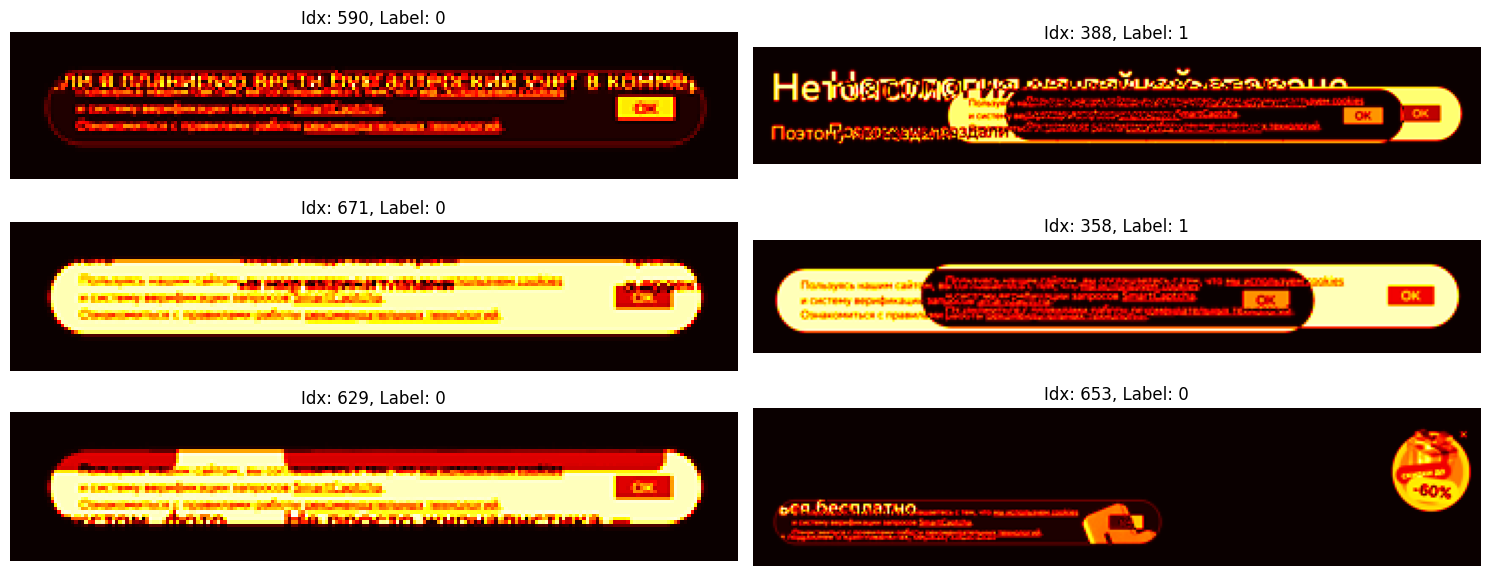

In [10]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(3, 2, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
y_scores = lr.predict_proba(X_test)[:, 1]

def result_with_another_treshold(my_threshold):    
    y_pred_custom = (y_scores >= my_threshold).astype(int)
    
    print(f"\n========== Результаты при пороге {my_threshold} ==========")
    print(classification_report(y_test, y_pred_custom))
    print("\nМатрица ошибок:")
    print(confusion_matrix(y_test, y_pred_custom))
    

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for t in thresholds:
    result_with_another_treshold(t)


========== Результаты при пороге 0.1 ==========
              precision    recall  f1-score   support

           0       0.82      0.25      0.39       126
           1       0.55      0.94      0.69       120

    accuracy                           0.59       246
   macro avg       0.68      0.60      0.54       246
weighted avg       0.69      0.59      0.54       246


Матрица ошибок:
[[ 32  94]
 [  7 113]]

========== Результаты при пороге 0.2 ==========
              precision    recall  f1-score   support

           0       0.85      0.40      0.54       126
           1       0.59      0.93      0.72       120

    accuracy                           0.65       246
   macro avg       0.72      0.66      0.63       246
weighted avg       0.72      0.65      0.63       246


Матрица ошибок:
[[ 50  76]
 [  9 111]]

========== Результаты при пороге 0.3 ==========
              precision    recall  f1-score   support

           0       0.87      0.71      0.79       126
          

```
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       126
           1       0.98      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246
```

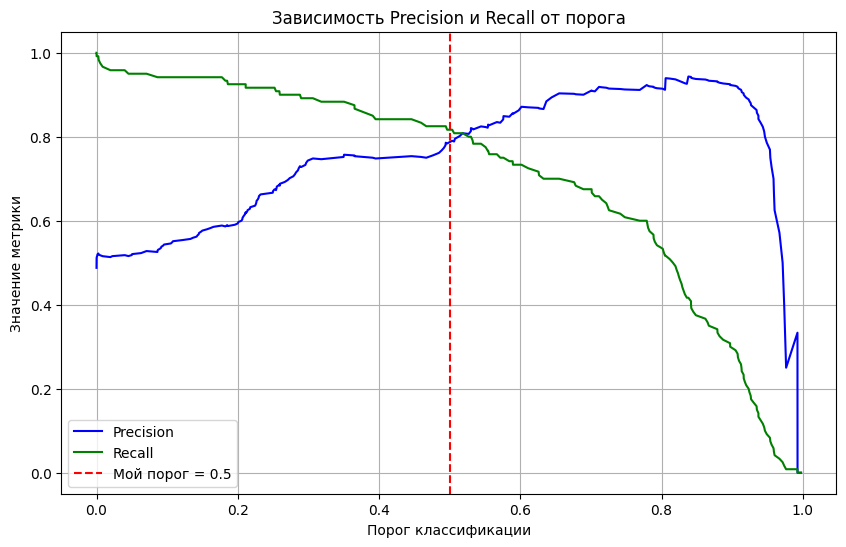

In [12]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds_pr, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Зависимость Precision и Recall от порога')
plt.axvline(x=0.5, color='r', linestyle='--', label='Мой порог = 0.5')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
X = joblib.load('X_cropped_diff_images_6_overeducation4.joblib')
X_coords = joblib.load('X_coords_diff_images_6_overeducation4.joblib')
y = joblib.load('y_labels_6_overeducation4.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 7548 изображений
Загружено 7548 координат левого верхнегно угла
Загружено 7548 лейблов


In [14]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

Размер датафрейма: (7548, 33)
Количество признаков: 32


### Переобучим наоборот: на 4к + 4к обучаем, на 110 и 800 валидация

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.3,
    random_state=69
)

lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       131
           1       0.76      0.78      0.77       115

    accuracy                           0.78       246
   macro avg       0.78      0.78      0.78       246
weighted avg       0.78      0.78      0.78       246



/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [20]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

Размер датафрейма: (818, 33)
Количество признаков: 32


In [21]:
y_pred = lr.predict(X_features)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       418
           1       0.82      0.81      0.81       400

    accuracy                           0.82       818
   macro avg       0.82      0.82      0.82       818
weighted avg       0.82      0.82      0.82       818



In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = joblib.load('X_cropped_diff_images_6_overeducation4.joblib')
X_coords = joblib.load('X_coords_diff_images_6_overeducation4.joblib')
y = joblib.load('y_labels_6_overeducation4.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")


df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.3,
    random_state=69
)

# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели логистической регрессии
lr = LogisticRegression(random_state=69, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

Загружено 7548 изображений
Загружено 7548 координат левого верхнегно угла
Загружено 7548 лейблов
Размер датафрейма: (7548, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1150
           1       0.97      0.97      0.97      1115

    accuracy                           0.97      2265
   macro avg       0.97      0.97      0.97      2265
weighted avg       0.97      0.97      0.97      2265



In [23]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

y_pred = lr.predict(X_features)

print(classification_report(y, y_pred))

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов
Размер датафрейма: (818, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
           1       0.49      1.00      0.66       400

    accuracy                           0.49       818
   macro avg       0.24      0.50      0.33       818
weighted avg       0.24      0.49      0.32       818



/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricW

In [24]:
from sklearn.svm import SVC


X = joblib.load('X_cropped_diff_images_6_overeducation4.joblib')
X_coords = joblib.load('X_coords_diff_images_6_overeducation4.joblib')
y = joblib.load('y_labels_6_overeducation4.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")


df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.3,
    random_state=69
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=69)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

Загружено 7548 изображений
Загружено 7548 координат левого верхнегно угла
Загружено 7548 лейблов
Размер датафрейма: (7548, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1150
           1       0.98      0.98      0.98      1115

    accuracy                           0.98      2265
   macro avg       0.98      0.98      0.98      2265
weighted avg       0.98      0.98      0.98      2265



In [25]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

X_scaled = scaler.transform(X_features)

y_pred = svm.predict(X_scaled)

print(classification_report(y, y_pred))

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов
Размер датафрейма: (818, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.64      0.14      0.23       418
           1       0.51      0.92      0.65       400

    accuracy                           0.52       818
   macro avg       0.57      0.53      0.44       818
weighted avg       0.58      0.52      0.44       818



In [27]:
from catboost import CatBoostClassifier


X = joblib.load('X_cropped_diff_images_6_overeducation4.joblib')
X_coords = joblib.load('X_coords_diff_images_6_overeducation4.joblib')
y = joblib.load('y_labels_6_overeducation4.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")


df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.3,
    random_state=69
)

catb = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=69,
    verbose=False
)
catb.fit(X_train, y_train)
y_pred = catb.predict(X_test)
print(classification_report(y_test, y_pred))

Загружено 7548 изображений
Загружено 7548 координат левого верхнегно угла
Загружено 7548 лейблов
Размер датафрейма: (7548, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1150
           1       1.00      0.99      0.99      1115

    accuracy                           0.99      2265
   macro avg       0.99      0.99      0.99      2265
weighted avg       0.99      0.99      0.99      2265



In [28]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")


y_pred = catb.predict(X_features)

print(classification_report(y, y_pred))

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов
Размер датафрейма: (818, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.68      0.17      0.28       418
           1       0.51      0.91      0.66       400

    accuracy                           0.54       818
   macro avg       0.60      0.54      0.47       818
weighted avg       0.60      0.54      0.46       818



In [29]:
X2 = joblib.load('X_cropped_diff_images_6_overeducation4.joblib')
X_coords2 = joblib.load('X_coords_diff_images_6_overeducation4.joblib')
y2 = joblib.load('y_labels_6_overeducation4.joblib')

print(f"Загружено {len(X2)} изображений")
print(f"Загружено {len(X_coords2)} координат левого верхнегно угла")
print(f"Загружено {len(y2)} лейблов")

Загружено 7548 изображений
Загружено 7548 координат левого верхнегно угла
Загружено 7548 лейблов


In [30]:
df_features2 = create_feature_dataset(X2, X_coords2)
df_features2['symmetry_score'] = compute_symmetry_score_enhanced(X2)
duplicated_pattern2 = detect_duplicated_pattern(X2)
df_features2['duplicated_pattern_best_score'] = duplicated_pattern2[0]
df_features2['duplicated_pattern_best_shift'] = duplicated_pattern2[1]
X_features2 = df_features2.drop(['sample_id'], axis=1)

X_combined = np.vstack([X_features, X_features2])
y_combined = np.hstack([y, y2])

print(f"Объединенный датасет: {len(X_combined)} образцов")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y_combined,
    test_size=0.4,
    random_state=69,
    stratify=y_combined
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.6,
    random_state=69,
    stratify=y_temp
)

print(f"Обучающая выборка: {len(X_train)} ({len(X_train)/len(X_combined)*100:.1f}%)")
print(f"Валидационная выборка: {len(X_val)} ({len(X_val)/len(X_combined)*100:.1f}%)")
print(f"Тестовая выборка: {len(X_test)} ({len(X_test)/len(X_combined)*100:.1f}%)")

catb = CatBoostClassifier(
    iterations=50,
    learning_rate=0.001,
    depth=3,
    l2_leaf_reg=3,
    subsample=0.8,
    random_seed=69,
    verbose=False,
    eval_metric='Recall'
)

catb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20,
    verbose=False
)

y_pred = catb.predict(X_test)
print(classification_report(y_test, y_pred))

Объединенный датасет: 8366 образцов
Обучающая выборка: 5019 (60.0%)
Валидационная выборка: 1338 (16.0%)
Тестовая выборка: 2009 (24.0%)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1007
           1       0.98      0.91      0.95      1002

    accuracy                           0.95      2009
   macro avg       0.95      0.95      0.95      2009
weighted avg       0.95      0.95      0.95      2009



Training on fold [0/5]
0:	learn: 0.8926610	test: 0.8822355	best: 0.8822355 (0)	total: 4.86ms	remaining: 238ms
1:	learn: 0.8981528	test: 0.8962076	best: 0.8962076 (1)	total: 9.2ms	remaining: 221ms
2:	learn: 0.9016475	test: 0.8962076	best: 0.8962076 (1)	total: 11.2ms	remaining: 175ms
3:	learn: 0.9051423	test: 0.8902196	best: 0.8962076 (1)	total: 15.1ms	remaining: 174ms
4:	learn: 0.8956565	test: 0.8822355	best: 0.8962076 (1)	total: 19.6ms	remaining: 177ms
5:	learn: 0.9011483	test: 0.8842315	best: 0.8962076 (1)	total: 23.9ms	remaining: 175ms
6:	learn: 0.9001498	test: 0.8862275	best: 0.8962076 (1)	total: 26.7ms	remaining: 164ms
7:	learn: 0.9056415	test: 0.8902196	best: 0.8962076 (1)	total: 31.6ms	remaining: 166ms
8:	learn: 0.8981528	test: 0.8842315	best: 0.8962076 (1)	total: 34.6ms	remaining: 158ms
9:	learn: 0.8966550	test: 0.8762475	best: 0.8962076 (1)	total: 36.1ms	remaining: 145ms
10:	learn: 0.9021468	test: 0.8822355	best: 0.8962076 (1)	total: 38.5ms	remaining: 137ms
11:	learn: 0.9036445

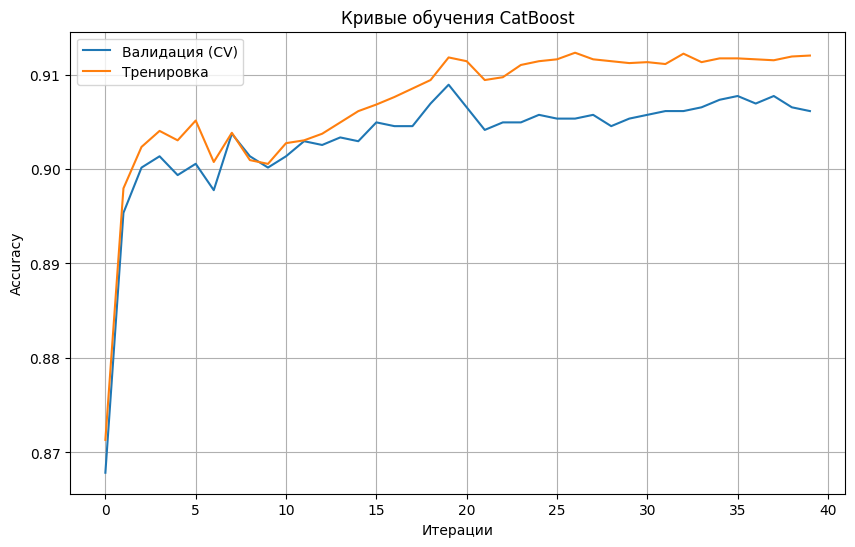

In [31]:
from catboost import Pool, cv

train_pool = Pool(X_train, y_train)
cv_params = {
    'iterations': 50,
    'depth': 3,
    'learning_rate': 0.01,
    'loss_function': 'Logloss',
    'l2_leaf_reg': 3,
    'subsample': 0.8,
    'verbose': True,
    'eval_metric': 'Recall',
    'early_stopping_rounds': 20
}

cv_data = cv(
    params=cv_params,
    pool=train_pool,
    fold_count=5,
    shuffle=True,
    return_models=False
)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(cv_data['iterations'], cv_data['test-Recall-mean'], label='Валидация (CV)')
plt.plot(cv_data['iterations'], cv_data['train-Recall-mean'], label='Тренировка')
plt.xlabel('Итерации')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Кривые обучения CatBoost')
plt.grid()
plt.show()

In [32]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")


y_pred = catb.predict(X_features)

print(classification_report(y, y_pred))

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов
Размер датафрейма: (818, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       418
           1       0.99      0.69      0.82       400

    accuracy                           0.85       818
   macro avg       0.88      0.84      0.84       818
weighted avg       0.88      0.85      0.84       818



In [34]:
y_scores = catb.predict_proba(X_features)[:, 1]

def result_with_another_treshold(my_threshold):    
    y_pred_custom = (y_scores >= my_threshold).astype(int)
    
    print(f"\n========== Результаты при пороге {my_threshold} ==========")
    print(classification_report(y, y_pred_custom))
    print("\nМатрица ошибок:")
    print(confusion_matrix(y, y_pred_custom))
    

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for t in thresholds:
    result_with_another_treshold(t)


========== Результаты при пороге 0.1 ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
           1       0.49      1.00      0.66       400

    accuracy                           0.49       818
   macro avg       0.24      0.50      0.33       818
weighted avg       0.24      0.49      0.32       818


Матрица ошибок:
[[  0 418]
 [  0 400]]

========== Результаты при пороге 0.2 ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
           1       0.49      1.00      0.66       400

    accuracy                           0.49       818
   macro avg       0.24      0.50      0.33       818
weighted avg       0.24      0.49      0.32       818


Матрица ошибок:
[[  0 418]
 [  0 400]]

========== Результаты при пороге 0.3 ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
          

/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

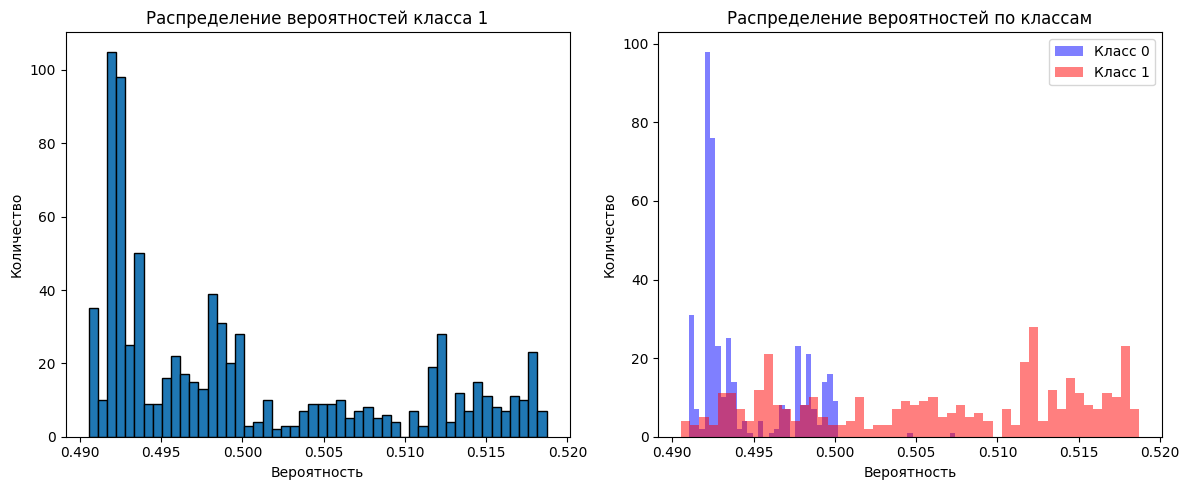

Статистика вероятностей:
Мин: 0.4905
Макс: 0.5187
Среднее: 0.5001
Медиана: 0.4972
Стандартное отклонение: 0.0087

Статистика для класса 0:
Мин: 0.4910
Макс: 0.5074
Среднее: 0.4943

Статистика для класса 1:
Мин: 0.4905
Макс: 0.5187
Среднее: 0.5062

Количество уникальных значений вероятностей: 329
Первые 20 уникальных значений: [0.4905349  0.49100192 0.491009   0.49111217 0.49112759 0.49143494
 0.49147604 0.49160171 0.49175257 0.49175963 0.4919705  0.49211658
 0.49214162 0.49217902 0.4926087  0.4926461  0.49266669 0.492672
 0.4926735  0.49269391]


In [35]:
plt.figure(figsize=(12, 5))

# Гистограмма вероятностей для класса 1
plt.subplot(1, 2, 1)
plt.hist(y_scores, bins=50, edgecolor='black')
plt.title('Распределение вероятностей класса 1')
plt.xlabel('Вероятность')
plt.ylabel('Количество')

# Раздельно для каждого класса
plt.subplot(1, 2, 2)
plt.hist(y_scores[y == 0], bins=50, alpha=0.5, label='Класс 0', color='blue')
plt.hist(y_scores[y == 1], bins=50, alpha=0.5, label='Класс 1', color='red')
plt.title('Распределение вероятностей по классам')
plt.xlabel('Вероятность')
plt.ylabel('Количество')
plt.legend()

plt.tight_layout()
plt.show()

# Статистика по вероятностям
print("Статистика вероятностей:")
print(f"Мин: {y_scores.min():.4f}")
print(f"Макс: {y_scores.max():.4f}")
print(f"Среднее: {y_scores.mean():.4f}")
print(f"Медиана: {np.median(y_scores):.4f}")
print(f"Стандартное отклонение: {y_scores.std():.4f}")

print("\nСтатистика для класса 0:")
print(f"Мин: {y_scores[y == 0].min():.4f}")
print(f"Макс: {y_scores[y == 0].max():.4f}")
print(f"Среднее: {y_scores[y == 0].mean():.4f}")

print("\nСтатистика для класса 1:")
print(f"Мин: {y_scores[y == 1].min():.4f}")
print(f"Макс: {y_scores[y == 1].max():.4f}")
print(f"Среднее: {y_scores[y == 1].mean():.4f}")

# Посмотрим на уникальные значения вероятностей
unique_probs = np.unique(y_scores)
print(f"\nКоличество уникальных значений вероятностей: {len(unique_probs)}")
print("Первые 20 уникальных значений:", unique_probs[:20])

In [40]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.3,
    random_state=69
)

catb = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=69,
    verbose=False
)

catb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20,
    verbose=False
)

y_pred = catb.predict(X_test)
print(classification_report(y_test, y_pred))

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов
Размер датафрейма: (818, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       131
           1       0.98      0.96      0.97       115

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246



Training on fold [0/5]
0:	learn: 0.7982456	test: 0.7543860	best: 0.7543860 (0)	total: 4.43ms	remaining: 217ms
1:	learn: 0.8947368	test: 0.8771930	best: 0.8771930 (1)	total: 7.38ms	remaining: 177ms
2:	learn: 0.8684211	test: 0.8596491	best: 0.8771930 (1)	total: 10.8ms	remaining: 169ms
3:	learn: 0.8421053	test: 0.8421053	best: 0.8771930 (1)	total: 16.3ms	remaining: 187ms
4:	learn: 0.8377193	test: 0.8421053	best: 0.8771930 (1)	total: 19.8ms	remaining: 178ms
5:	learn: 0.8552632	test: 0.8596491	best: 0.8771930 (1)	total: 23.5ms	remaining: 172ms
6:	learn: 0.8421053	test: 0.8596491	best: 0.8771930 (1)	total: 27.4ms	remaining: 168ms
7:	learn: 0.8684211	test: 0.8596491	best: 0.8771930 (1)	total: 31.2ms	remaining: 164ms
8:	learn: 0.8640351	test: 0.8771930	best: 0.8771930 (1)	total: 34.2ms	remaining: 156ms
9:	learn: 0.8684211	test: 0.8771930	best: 0.8771930 (1)	total: 36.2ms	remaining: 145ms
10:	learn: 0.8552632	test: 0.8771930	best: 0.8771930 (1)	total: 39.3ms	remaining: 139ms
11:	learn: 0.846491

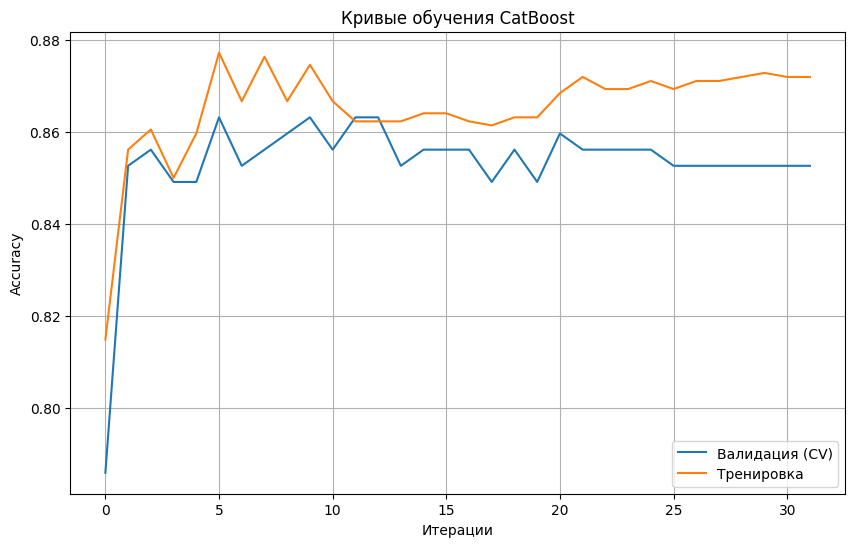

In [42]:
train_pool = Pool(X_train, y_train)
cv_params = {
    'iterations': 50,
    'depth': 3,
    'learning_rate': 0.01,
    'loss_function': 'Logloss',
    'l2_leaf_reg': 3,
    'subsample': 0.8,
    'verbose': True,
    'eval_metric': 'Recall',
    'early_stopping_rounds': 20
}

cv_data = cv(
    params=cv_params,
    pool=train_pool,
    fold_count=5,
    shuffle=True,
    return_models=False
)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(cv_data['iterations'], cv_data['test-Recall-mean'], label='Валидация (CV)')
plt.plot(cv_data['iterations'], cv_data['train-Recall-mean'], label='Тренировка')
plt.xlabel('Итерации')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Кривые обучения CatBoost')
plt.grid()
plt.show()

In [43]:
X = joblib.load('X_cropped_diff_images_6_overeducation4.joblib')
X_coords = joblib.load('X_coords_diff_images_6_overeducation4.joblib')
y = joblib.load('y_labels_6_overeducation4.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")


df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]
X_features = df_features.drop(['sample_id'], axis=1)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

y_pred = catb.predict(X_features)

print(classification_report(y, y_pred))

Загружено 7548 изображений
Загружено 7548 координат левого верхнегно угла
Загружено 7548 лейблов
Размер датафрейма: (7548, 33)
Количество признаков: 32
              precision    recall  f1-score   support

           0       0.94      0.50      0.65      3774
           1       0.66      0.97      0.79      3774

    accuracy                           0.73      7548
   macro avg       0.80      0.73      0.72      7548
weighted avg       0.80      0.73      0.72      7548



In [44]:
y_scores = catb.predict_proba(X_features)[:, 1]

def result_with_another_treshold(my_threshold):    
    y_pred_custom = (y_scores >= my_threshold).astype(int)
    
    print(f"\n========== Результаты при пороге {my_threshold} ==========")
    print(classification_report(y, y_pred_custom))
    print("\nМатрица ошибок:")
    print(confusion_matrix(y, y_pred_custom))
    

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for t in thresholds:
    result_with_another_treshold(t)


========== Результаты при пороге 0.1 ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3774
           1       0.50      1.00      0.67      3774

    accuracy                           0.50      7548
   macro avg       0.25      0.50      0.33      7548
weighted avg       0.25      0.50      0.33      7548


Матрица ошибок:
[[   0 3774]
 [   0 3774]]

========== Результаты при пороге 0.2 ==========
              precision    recall  f1-score   support

           0       0.17      0.00      0.00      3774
           1       0.50      0.99      0.66      3774

    accuracy                           0.50      7548
   macro avg       0.34      0.50      0.33      7548
weighted avg       0.34      0.50      0.33      7548


Матрица ошибок:
[[   4 3770]
 [  19 3755]]

========== Результаты при пороге 0.3 ==========
              precision    recall  f1-score   support

           0       0.91      0.13      0.22      3774
  

/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/ml_projects/ml_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}